# Customer Churn Prediction
### Step 1 — Data Cleaning & Preprocessing
**Dataset:** `customer_churn_data.csv` | 1000 rows × 10 columns

##  Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## Step 1 — Load Data

In [2]:
df = pd.read_csv('customer_churn_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (1000, 10)


,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


##  Step 2 — Dataset Audit (always do this first)

In [3]:
print('─'*40)
print('DATA TYPES')
print('─'*40)
print(df.dtypes)
print()
print('─'*40)
print('MISSING VALUES')
print('─'*40)
print(df.isnull().sum())
print()
print('─'*40)
print('DUPLICATES:', df.duplicated().sum())
print('─'*40)

────────────────────────────────────────
DATA TYPES
────────────────────────────────────────
CustomerID           int64
Age                  int64
Gender              object
Tenure               int64
MonthlyCharges     float64
ContractType        object
InternetService     object
TotalCharges       float64
TechSupport         object
Churn               object
dtype: object

────────────────────────────────────────
MISSING VALUES
────────────────────────────────────────
CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

────────────────────────────────────────
DUPLICATES: 0
────────────────────────────────────────


In [4]:
# Statistical summary of numerical columns
df.describe().round(2)

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,44.67,18.97,74.39,1404.36
std,288.82,9.80,18.89,25.71,1571.76
min,1.00,12.00,0.00,30.00,0.00
25%,250.75,38.00,5.00,52.36,345.22
50%,500.50,45.00,13.00,74.06,872.87
75%,750.25,51.00,26.00,96.10,1900.18
max,1000.00,83.00,122.00,119.96,12416.25


In [5]:
# Unique values in categorical columns
cat_cols = ['Gender', 'ContractType', 'InternetService', 'TechSupport', 'Churn']
for col in cat_cols:
    print(f'{col:20s} → {df[col].unique()}')

Gender               → ['Male' 'Female']
ContractType         → ['Month-to-Month' 'One-Year' 'Two-Year']
InternetService      → ['Fiber Optic' 'DSL' nan]
TechSupport          → ['Yes' 'No']
Churn                → ['Yes' 'No']


## Step 3 — EDA (Exploratory Data Analysis)

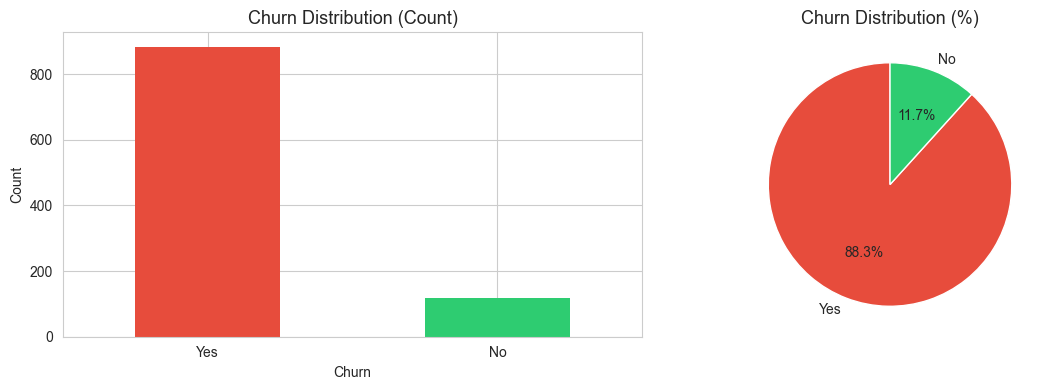

⚠️  SEVERE CLASS IMBALANCE — 88.3% Yes vs 11.7% No
   Do NOT use accuracy as metric. Use F1-score and PR-AUC instead.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn count
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#E74C3C', '#2ECC71'], edgecolor='none')
axes[0].set_title('Churn Distribution (Count)', fontsize=13)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Churn percentage
df['Churn'].value_counts(normalize=True).mul(100).plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#E74C3C', '#2ECC71'], startangle=90)
axes[1].set_title('Churn Distribution (%)', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print('⚠️  SEVERE CLASS IMBALANCE — 88.3% Yes vs 11.7% No')
print('   Do NOT use accuracy as metric. Use F1-score and PR-AUC instead.')

C:\Users\3rd Eye Technology\AppData\Local\Temp\ipykernel_5752\1178237845.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0,2], palette=['#2ECC71','#E74C3C'])


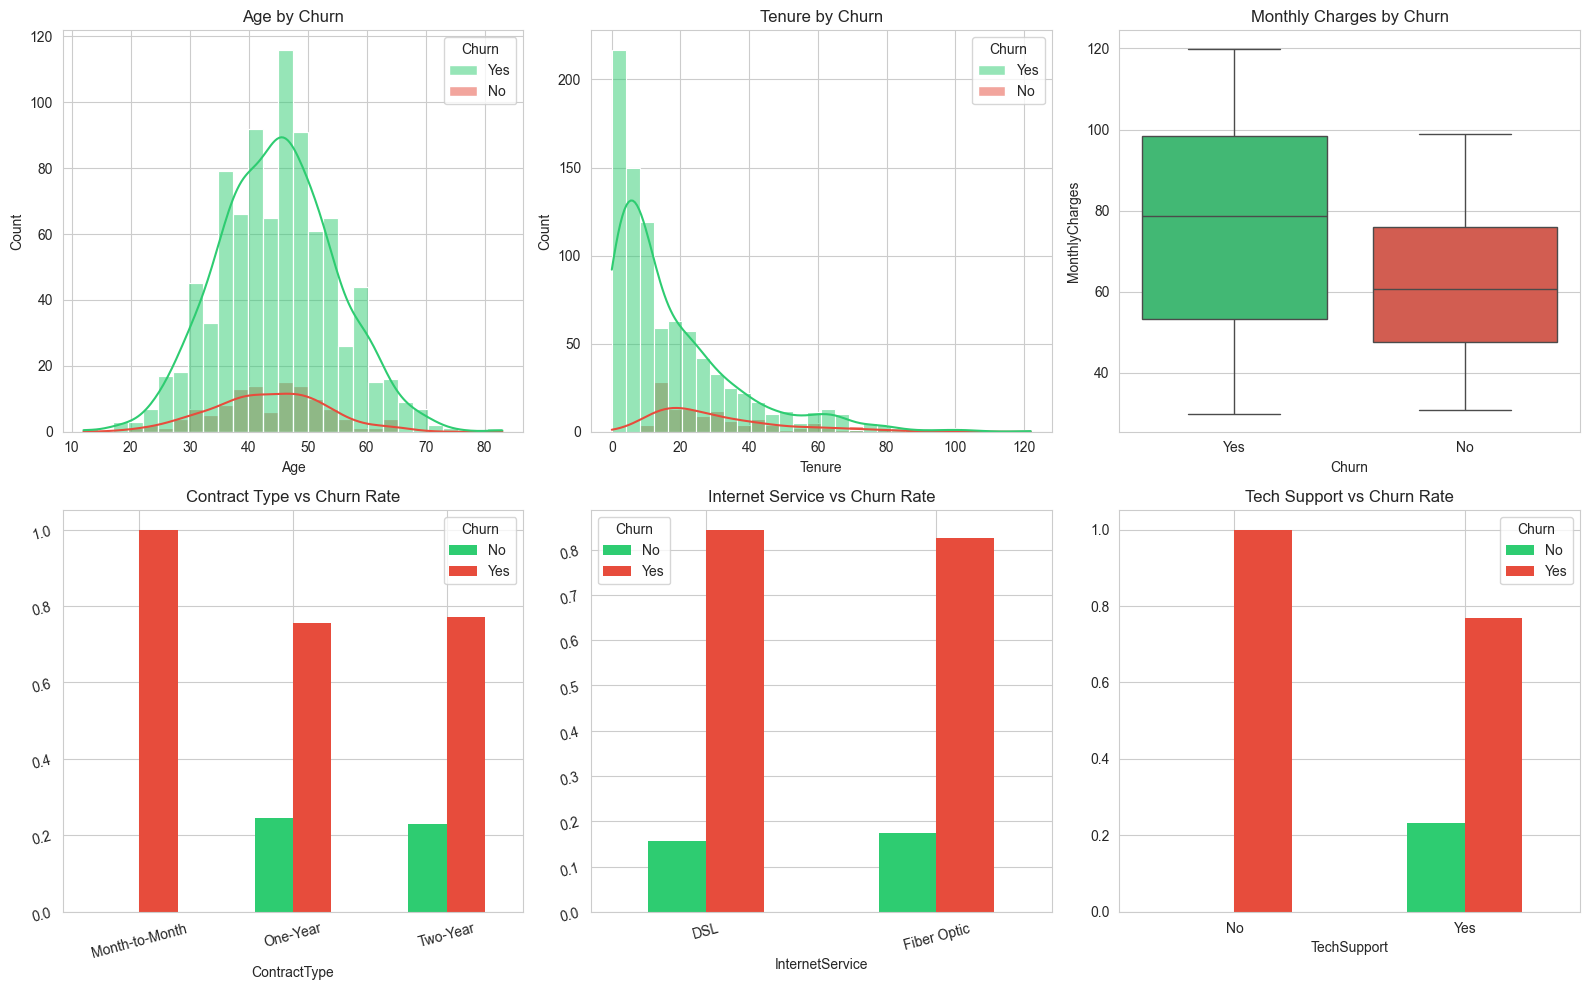

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Age distribution
sns.histplot(data=df, x='Age', hue='Churn', kde=True, ax=axes[0,0], palette=['#2ECC71','#E74C3C'])
axes[0,0].set_title('Age by Churn')

# Tenure distribution
sns.histplot(data=df, x='Tenure', hue='Churn', kde=True, ax=axes[0,1], palette=['#2ECC71','#E74C3C'])
axes[0,1].set_title('Tenure by Churn')

# Monthly Charges
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0,2], palette=['#2ECC71','#E74C3C'])
axes[0,2].set_title('Monthly Charges by Churn')

# Contract Type
ct = df.groupby('ContractType')['Churn'].value_counts(normalize=True).unstack()
ct.plot(kind='bar', ax=axes[1,0], color=['#2ECC71','#E74C3C'], edgecolor='none')
axes[1,0].set_title('Contract Type vs Churn Rate')
axes[1,0].tick_params(rotation=15)

# Internet Service
isvc = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()
isvc.plot(kind='bar', ax=axes[1,1], color=['#2ECC71','#E74C3C'], edgecolor='none')
axes[1,1].set_title('Internet Service vs Churn Rate')
axes[1,1].tick_params(rotation=15)

# Tech Support
ts = df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack()
ts.plot(kind='bar', ax=axes[1,2], color=['#2ECC71','#E74C3C'], edgecolor='none')
axes[1,2].set_title('Tech Support vs Churn Rate')
axes[1,2].tick_params(rotation=0)

plt.tight_layout()
plt.show()

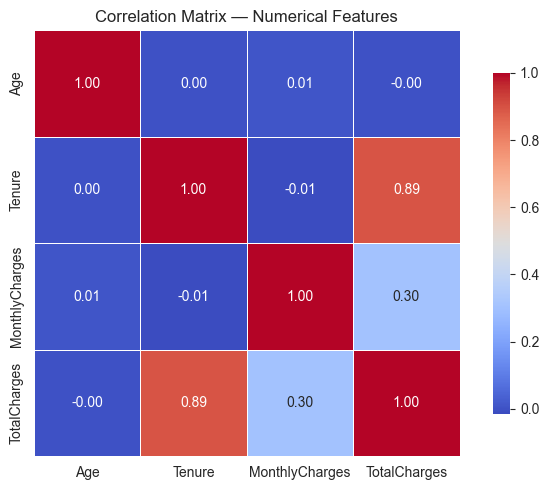

In [8]:
# Correlation heatmap (numerical columns only)
num_cols_temp = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[num_cols_temp].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

## Step 4 — Data Cleaning

In [9]:
# Drop CustomerID — just a row number, no predictive value
df.drop(columns=['CustomerID'], inplace=True)
print('✓ Dropped CustomerID')
print('Columns remaining:', df.columns.tolist())

✓ Dropped CustomerID
Columns remaining: ['Age', 'Gender', 'Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'TotalCharges', 'TechSupport', 'Churn']


In [10]:
# Handle missing values in InternetService (297 missing = 29.7%)
# Reason: these are customers with NO internet → fill with 'No Service'
print('Missing before:', df['InternetService'].isnull().sum())
df['InternetService'] = df['InternetService'].fillna('No Service')
print('Missing after: ', df['InternetService'].isnull().sum())

# Fix TotalCharges dtype and handle any coercion NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print('\n✓ All missing values handled')
print('Total missing now:', df.isnull().sum().sum())

Missing before: 297
Missing after:  0

✓ All missing values handled
Total missing now: 0


## Step 5 — Encoding

In [11]:
# Encode target variable: Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print('✓ Target encoded')
print(df['Churn'].value_counts())

✓ Target encoded
Churn
1    883
0    117
Name: count, dtype: int64


In [12]:
# Binary columns → Label Encoding (only 2 values, order doesn't matter)
le = LabelEncoder()
df['Gender']     = le.fit_transform(df['Gender'])           # Male=0, Female=1
df['TechSupport'] = df['TechSupport'].map({'No': 0, 'Yes': 1})

# Multi-class columns → One-Hot Encoding
# WHY? Label encoding implies ordering (0 < 1 < 2) which is wrong for categories
df = pd.get_dummies(df, columns=['ContractType', 'InternetService'], drop_first=False)

# Convert bool dummy columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print('✓ Encoding done')
print('Columns now:', df.columns.tolist())
df.head(3)

✓ Encoding done
Columns now: ['Age', 'Gender', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'TechSupport', 'Churn', 'ContractType_Month-to-Month', 'ContractType_One-Year', 'ContractType_Two-Year', 'InternetService_DSL', 'InternetService_Fiber Optic', 'InternetService_No Service']


,Age,Gender,Tenure,MonthlyCharges,TotalCharges,TechSupport,Churn,ContractType_Month-to-Month,ContractType_One-Year,ContractType_Two-Year,InternetService_DSL,InternetService_Fiber Optic,InternetService_No Service
0,49,1,4,88.35,353.40,1,1,1,0,0,0,1,0
1,43,1,0,36.67,0.00,1,1,1,0,0,0,1,0
2,51,0,2,63.79,127.58,0,1,1,0,0,0,1,0


## Step 6 — Feature Engineering

In [13]:
# AvgMonthlySpend: how much the customer pays per month on average
# (handles Tenure=0 edge case for brand new customers)
df['AvgMonthlySpend'] = df.apply(
    lambda row: row['TotalCharges'] / row['Tenure'] if row['Tenure'] > 0
    else row['MonthlyCharges'], axis=1
)

# ChargeDeviation: difference between actual charge and average
# High deviation = charges fluctuating = potential dissatisfaction signal
df['ChargeDeviation'] = abs(df['MonthlyCharges'] - df['AvgMonthlySpend'])

print('✓ Feature engineering done')
print('New features added: AvgMonthlySpend, ChargeDeviation')
df[['Tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'ChargeDeviation']].head()

✓ Feature engineering done
New features added: AvgMonthlySpend, ChargeDeviation


,Tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,ChargeDeviation
0,4,88.35,353.40,88.35,0.0
1,0,36.67,0.00,36.67,0.0
2,2,63.79,127.58,63.79,0.0
3,8,102.34,818.72,102.34,0.0
4,32,69.01,2208.32,69.01,0.0


##  Step 7 — Train / Test Split

In [14]:
X = df.drop(columns=['Churn'])
y = df['Churn']

# stratify=y → ensures both splits have the same 88/12 churn ratio
# random_state=42 → reproducible results every run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.3f}')
print(f'Test  churn rate: {y_test.mean():.3f}')
print('✓ Churn rate preserved in both splits (stratify worked)')

X_train: (800, 14) | X_test: (200, 14)
Train churn rate: 0.882
Test  churn rate: 0.885
✓ Churn rate preserved in both splits (stratify worked)


## Step 8 — Feature Scaling

In [15]:
num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges',
            'AvgMonthlySpend', 'ChargeDeviation']

scaler = StandardScaler()

# IMPORTANT: fit ONLY on train, then transform both
# Fitting on full data = data leakage (test info leaks into training)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])  # fit + transform
X_test[num_cols]  = scaler.transform(X_test[num_cols])        # transform only

print('✓ Scaling done — mean ≈ 0, std ≈ 1 for all numerical columns')
X_train[num_cols].describe().round(2)

✓ Scaling done — mean ≈ 0, std ≈ 1 for all numerical columns


,Age,Tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,ChargeDeviation
count,800.00,800.00,800.00,800.00,800.00,800.00
mean,0.00,0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.79,-1.00,-1.73,-0.89,-1.73,-0.40
25%,-0.72,-0.74,-0.85,-0.67,-0.85,-0.40
50%,0.00,-0.31,0.01,-0.34,0.01,-0.40
75%,0.62,0.37,0.85,0.30,0.85,-0.40
max,3.93,4.54,1.76,6.96,1.76,3.02


## Preprocessing Complete — Summary

In [1]:
print('='*55)
print('PREPROCESSING SUMMARY')
print('='*55)
print(f'  Total rows         : 1000')
print(f'  Final features (X) : {X_train.shape[1]}')
print(f'  Train samples      : {X_train.shape[0]}')
print(f'  Test  samples      : {X_test.shape[0]}')
print(f'  Missing values     : {df.isnull().sum().sum()}')
print(f'  Duplicates         : 0')
print()
print('  Steps completed:')
print('  [✓] Dropped CustomerID')
print('  [✓] Filled InternetService NaN → No Service')
print('  [✓] Encoded target (Churn: Yes=1, No=0)')
print('  [✓] Label encoded binary cols (Gender, TechSupport)')
print('  [✓] One-hot encoded multi-class cols (ContractType, InternetService)')
print('  [✓] Engineered AvgMonthlySpend + ChargeDeviation')
print('  [✓] Stratified train/test split (80/20)')
print('  [✓] StandardScaler (fit on train only)')
print()
print('  ⚠️  Class imbalance: 88.3% churn')


PREPROCESSING SUMMARY
  Total rows         : 1000


NameError: name 'X_train' is not defined